Será que é possível classificarmos o tipo de bebida dado alguns atributos como volume, quantidade de calorias e quantidade de cafeína?

Na aula de hoje vamos explorar o dataset caffeine para construirmos um classificador com base em modelos de árvores.

Atributos
* bebida: nome da bebida.
* Volume (ml): Quantidade em volume.
* Calorias: Quantidade de calorias.
* Cafeína(mg): Quantidade de cafeína.
* tipo: tipo de bebida. (Café, Bebidas Energéticas, Shots Energéticos, Refrigerantes, Chá, Água)

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz

In [37]:
url_caffeine = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/refs/heads/main/Machine-Learning/caffeine.csv"
caffeine = pd.read_csv(url_caffeine)

In [38]:
caffeine.shape

(610, 5)

In [39]:
caffeine.describe()

,Volume (ml),Calories,Caffeine (mg)
count,610.000000,610.000000,610.000000
mean,346.543630,75.527869,134.693443
std,143.747738,94.799919,155.362861
min,7.393375,0.000000,0.000000
25%,236.588000,0.000000,50.000000
50%,354.882000,25.000000,100.000000
75%,473.176000,140.000000,160.000000
max,1419.528000,830.000000,1555.000000


In [40]:
caffeine.head()

,drink,Volume (ml),Calories,Caffeine (mg),type
0,Costa Coffee,256.993715,0,277,Coffee
1,Coffee Friend Brewed Coffee,250.191810,0,145,Coffee
2,Hell Energy Coffee,250.191810,150,100,Coffee
3,Killer Coffee (AU),250.191810,0,430,Coffee
4,Nescafe Gold,250.191810,0,66,Coffee


In [41]:
caffeine.isnull().sum()

,0
drink,0
Volume (ml),0
Calories,0
Caffeine (mg),0
type,0


In [42]:
set(caffeine["type"])

{'Coffee', 'Energy Drinks', 'Energy Shots', 'Soft Drinks', 'Tea', 'Water'}

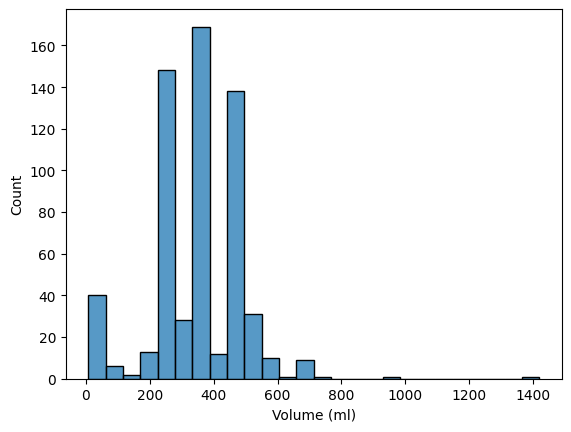

In [43]:
sns.histplot(data=caffeine,x="Volume (ml)")
plt.show()

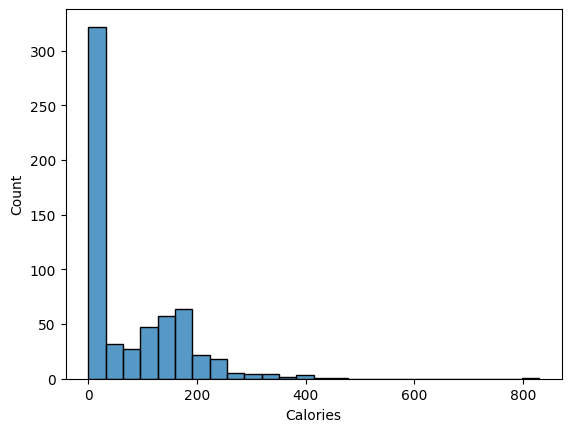

In [44]:
sns.histplot(data=caffeine,x="Calories")
plt.show()

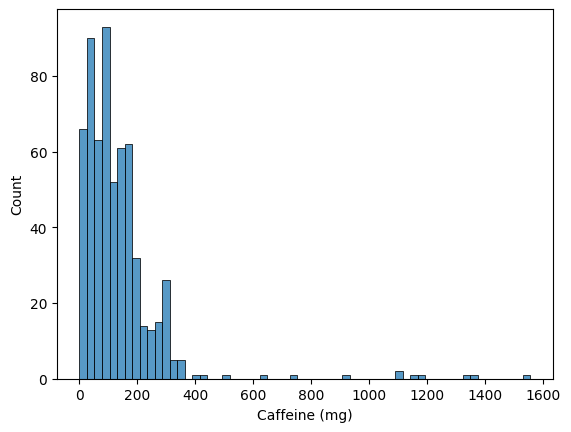

In [45]:
sns.histplot(data=caffeine,x="Caffeine (mg)")
plt.show()

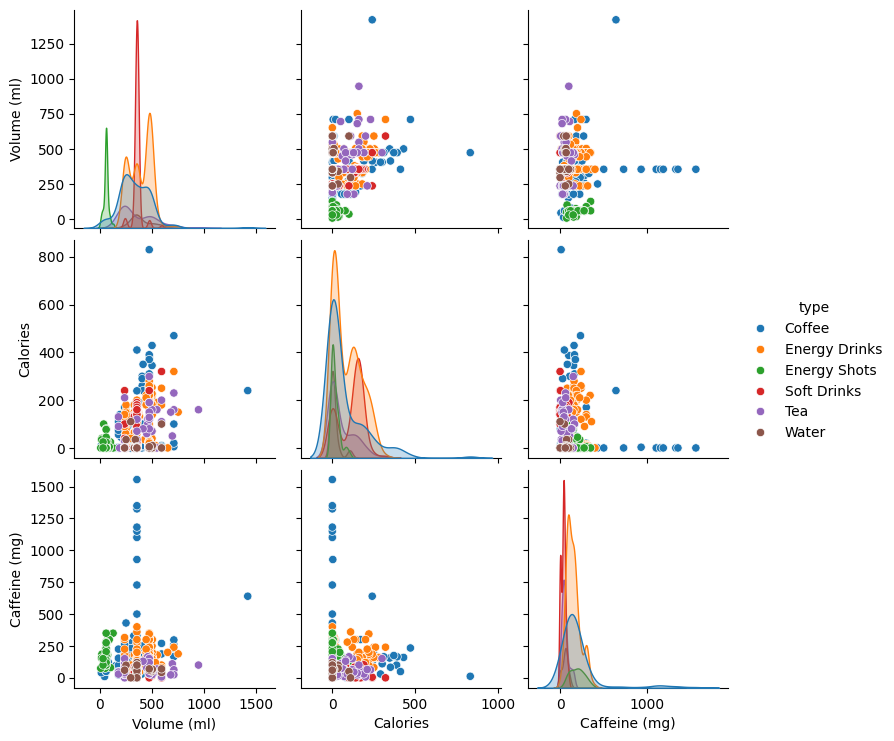

In [46]:
sns.pairplot(data=caffeine,hue="type")
plt.show()

In [47]:
x=caffeine.drop(columns=["type","drink"])
y=caffeine["type"]

In [48]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=7)

In [49]:
dt = DecisionTreeClassifier(random_state=7, criterion='gini', max_depth = 3)

In [50]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=7)

In [51]:
y_predito = dt.predict(x_test)

[Text(0.5, 0.875, 'x[2] <= 76.5\ngini = 0.752\nsamples = 488\nvalue = [138, 175, 29, 72, 53, 21]'),
 Text(0.25, 0.625, 'x[0] <= 312.888\ngini = 0.741\nsamples = 171\nvalue = [28, 16, 1, 67, 42, 17]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[0] <= 118.708\ngini = 0.653\nsamples = 60\nvalue = [24, 6, 1, 3, 25, 1]'),
 Text(0.0625, 0.125, 'gini = 0.219\nsamples = 8\nvalue = [7, 0, 1, 0, 0, 0]'),
 Text(0.1875, 0.125, 'gini = 0.645\nsamples = 52\nvalue = [17, 6, 0, 3, 25, 1]'),
 Text(0.375, 0.375, 'x[0] <= 367.451\ngini = 0.614\nsamples = 111\nvalue = [4, 10, 0, 64, 17, 16]'),
 Text(0.3125, 0.125, 'gini = 0.367\nsamples = 79\nvalue = [1, 4, 0, 62, 3, 9]'),
 Text(0.4375, 0.125, 'gini = 0.713\nsamples = 32\nvalue = [3, 6, 0, 2, 14, 7]'),
 Text(0.75, 0.625, 'x[0] <= 138.404\ngini = 0.619\nsamples = 317\nvalue = [110.0, 159.0, 28.0, 5.0, 11.0, 4.0]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[2] <= 131.5\ngini = 0.124\nsamples = 30\nvalue = [2, 0, 28, 0, 0, 0]'),
 Text(0

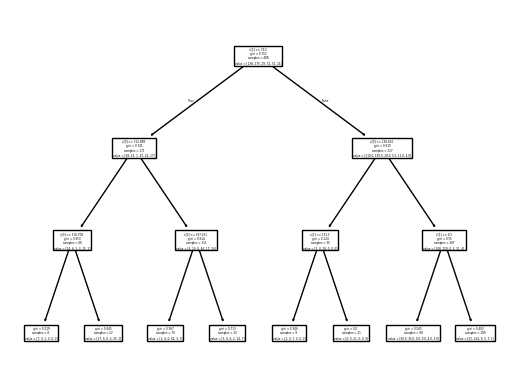

In [52]:
tree.plot_tree(dt)

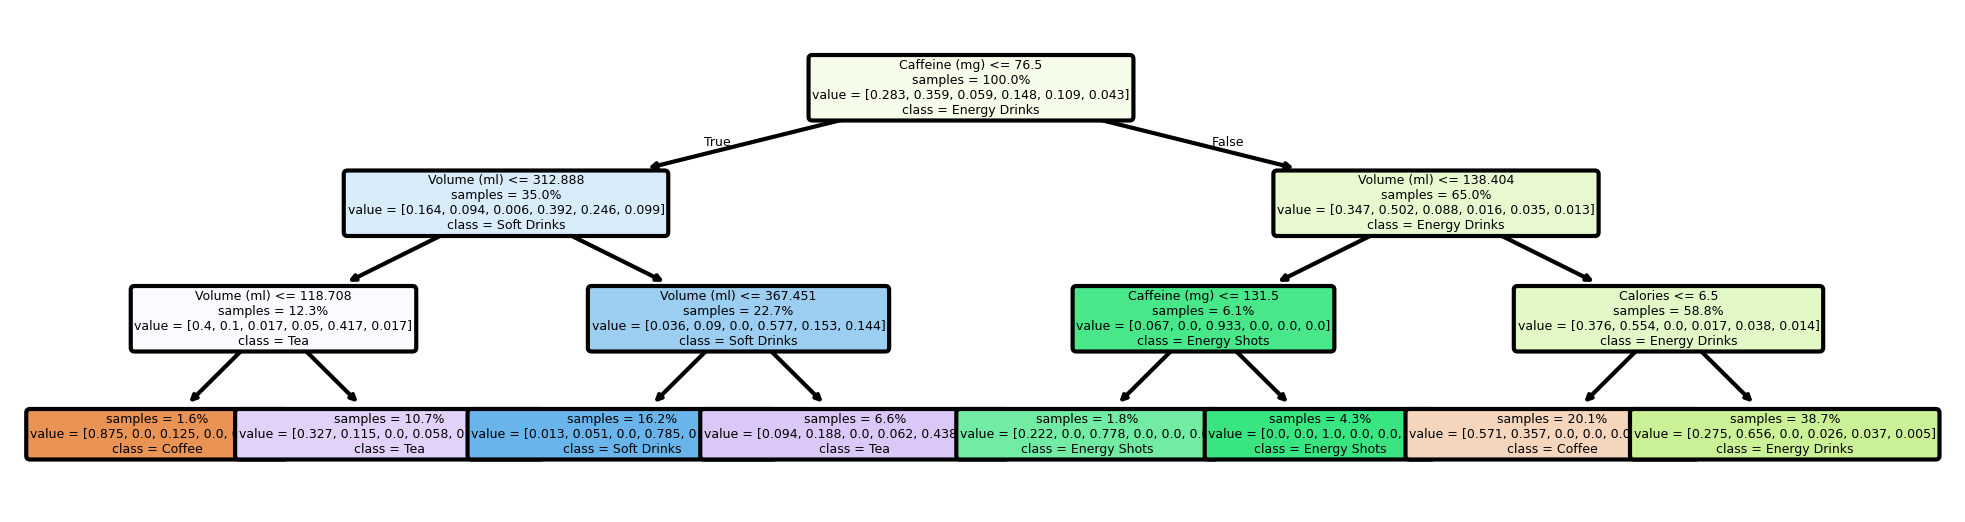

In [53]:
class_names = ['Coffee', 'Energy Drinks', 'Energy Shots', 'Soft Drinks', 'Tea', 'Water']
label_names = ['Volume (ml)',	'Calories',	'Caffeine (mg)'	]

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (8,2), dpi=300)

tree.plot_tree(dt,
               feature_names = label_names,
               class_names=class_names,
               filled = True,
               rounded=True,
               max_depth=3,        # 🔑 ESSENCIAL
               impurity=False,     # remove entropy
               proportion=True,    # evita números gigantes
               fontsize=3)          # fonte pequena

fig.savefig('imagename.png')

In [54]:
print(accuracy_score(y_test,y_predito))

0.6557377049180327


In [55]:
caffeine["type"].value_counts()

,count
type,
Energy Drinks,219
Coffee,173
Soft Drinks,90
Tea,66
Energy Shots,36
Water,26


Analisei que o Energy Drinks é muito maior do que as outras classes, o que pode impactar.
### Classes desbalanceadas e Random Forest

Quando a variável target está desbalanceada, métricas como acurácia podem ser prejudicadas, principalmente se a classe minoritária for relevante para o problema.

O **Random Forest** é um algoritmo relativamente robusto a desequilíbrios de classe, mas ainda assim pode se beneficiar de algumas estratégias de ajuste.

#### 1. Ajuste do parâmetro `class_weight`
O parâmetro `class_weight` permite atribuir pesos diferentes para cada classe.  
Ao usar `class_weight="balanced"`, o modelo ajusta automaticamente os pesos com base na frequência das classes, dando mais importância à classe minoritária.

#### 2. Técnicas de reamostragem
Outra abordagem é equilibrar os dados antes do treinamento:

- **Oversampling**: aumenta o número de observações da classe minoritária, por meio de duplicação ou geração de novos exemplos.
- **Undersampling**: reduz o número de observações da classe majoritária.

Essas técnicas ajudam a garantir que o modelo seja treinado com quantidades mais equilibradas de dados por classe.

As abordagens podem ser usadas de forma isolada ou combinadas. Independentemente da estratégia escolhida, o ajuste adequado dos hiperparâmetros é fundamental para obter bons resultados em modelos de machine learning.

In [56]:
from imblearn.over_sampling import SMOTE

In [57]:
oversample = SMOTE()
x_train_os, y_train_os = oversample.fit_resample(x_train, y_train) # Aplicar SMOTE para oversampling da classe minoritária

Nesse exemplo, SMOTE é utilizado para gerar dados sintéticos e equilibrar as classes antes de ajustar o modelo de Random Forest. Note que o método fit_resample é utilizado para aplicar o oversampling na classe minoritária. Por fim, o modelo é avaliado com a métrica de acurácia no conjunto de teste.

Oversampling envolve a criação de mais exemplos para a classe minoritária, aumentando sua representação no conjunto de dados. As técnicas comuns de oversampling incluem a replicação de exemplos existentes (cópia de exemplos da classe minoritária), a geração sintética de novos exemplos com base em exemplos existentes, como a técnica SMOTE (Synthetic Minority Over-sampling Technique), ou a combinação de ambas as abordagens.

In [58]:
x_train.shape

(488, 3)

In [59]:
x_train_os.shape

(1050, 3)

In [60]:
rf = RandomForestClassifier(criterion= 'entropy', n_estimators=80, max_depth = 7, class_weight = 'balanced', random_state=7)
rf.fit(x_train_os, y_train_os)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=7, n_estimators=80, random_state=7)

In [61]:
estimator_rf = rf.estimators_

In [62]:
len(rf.estimators_)

80

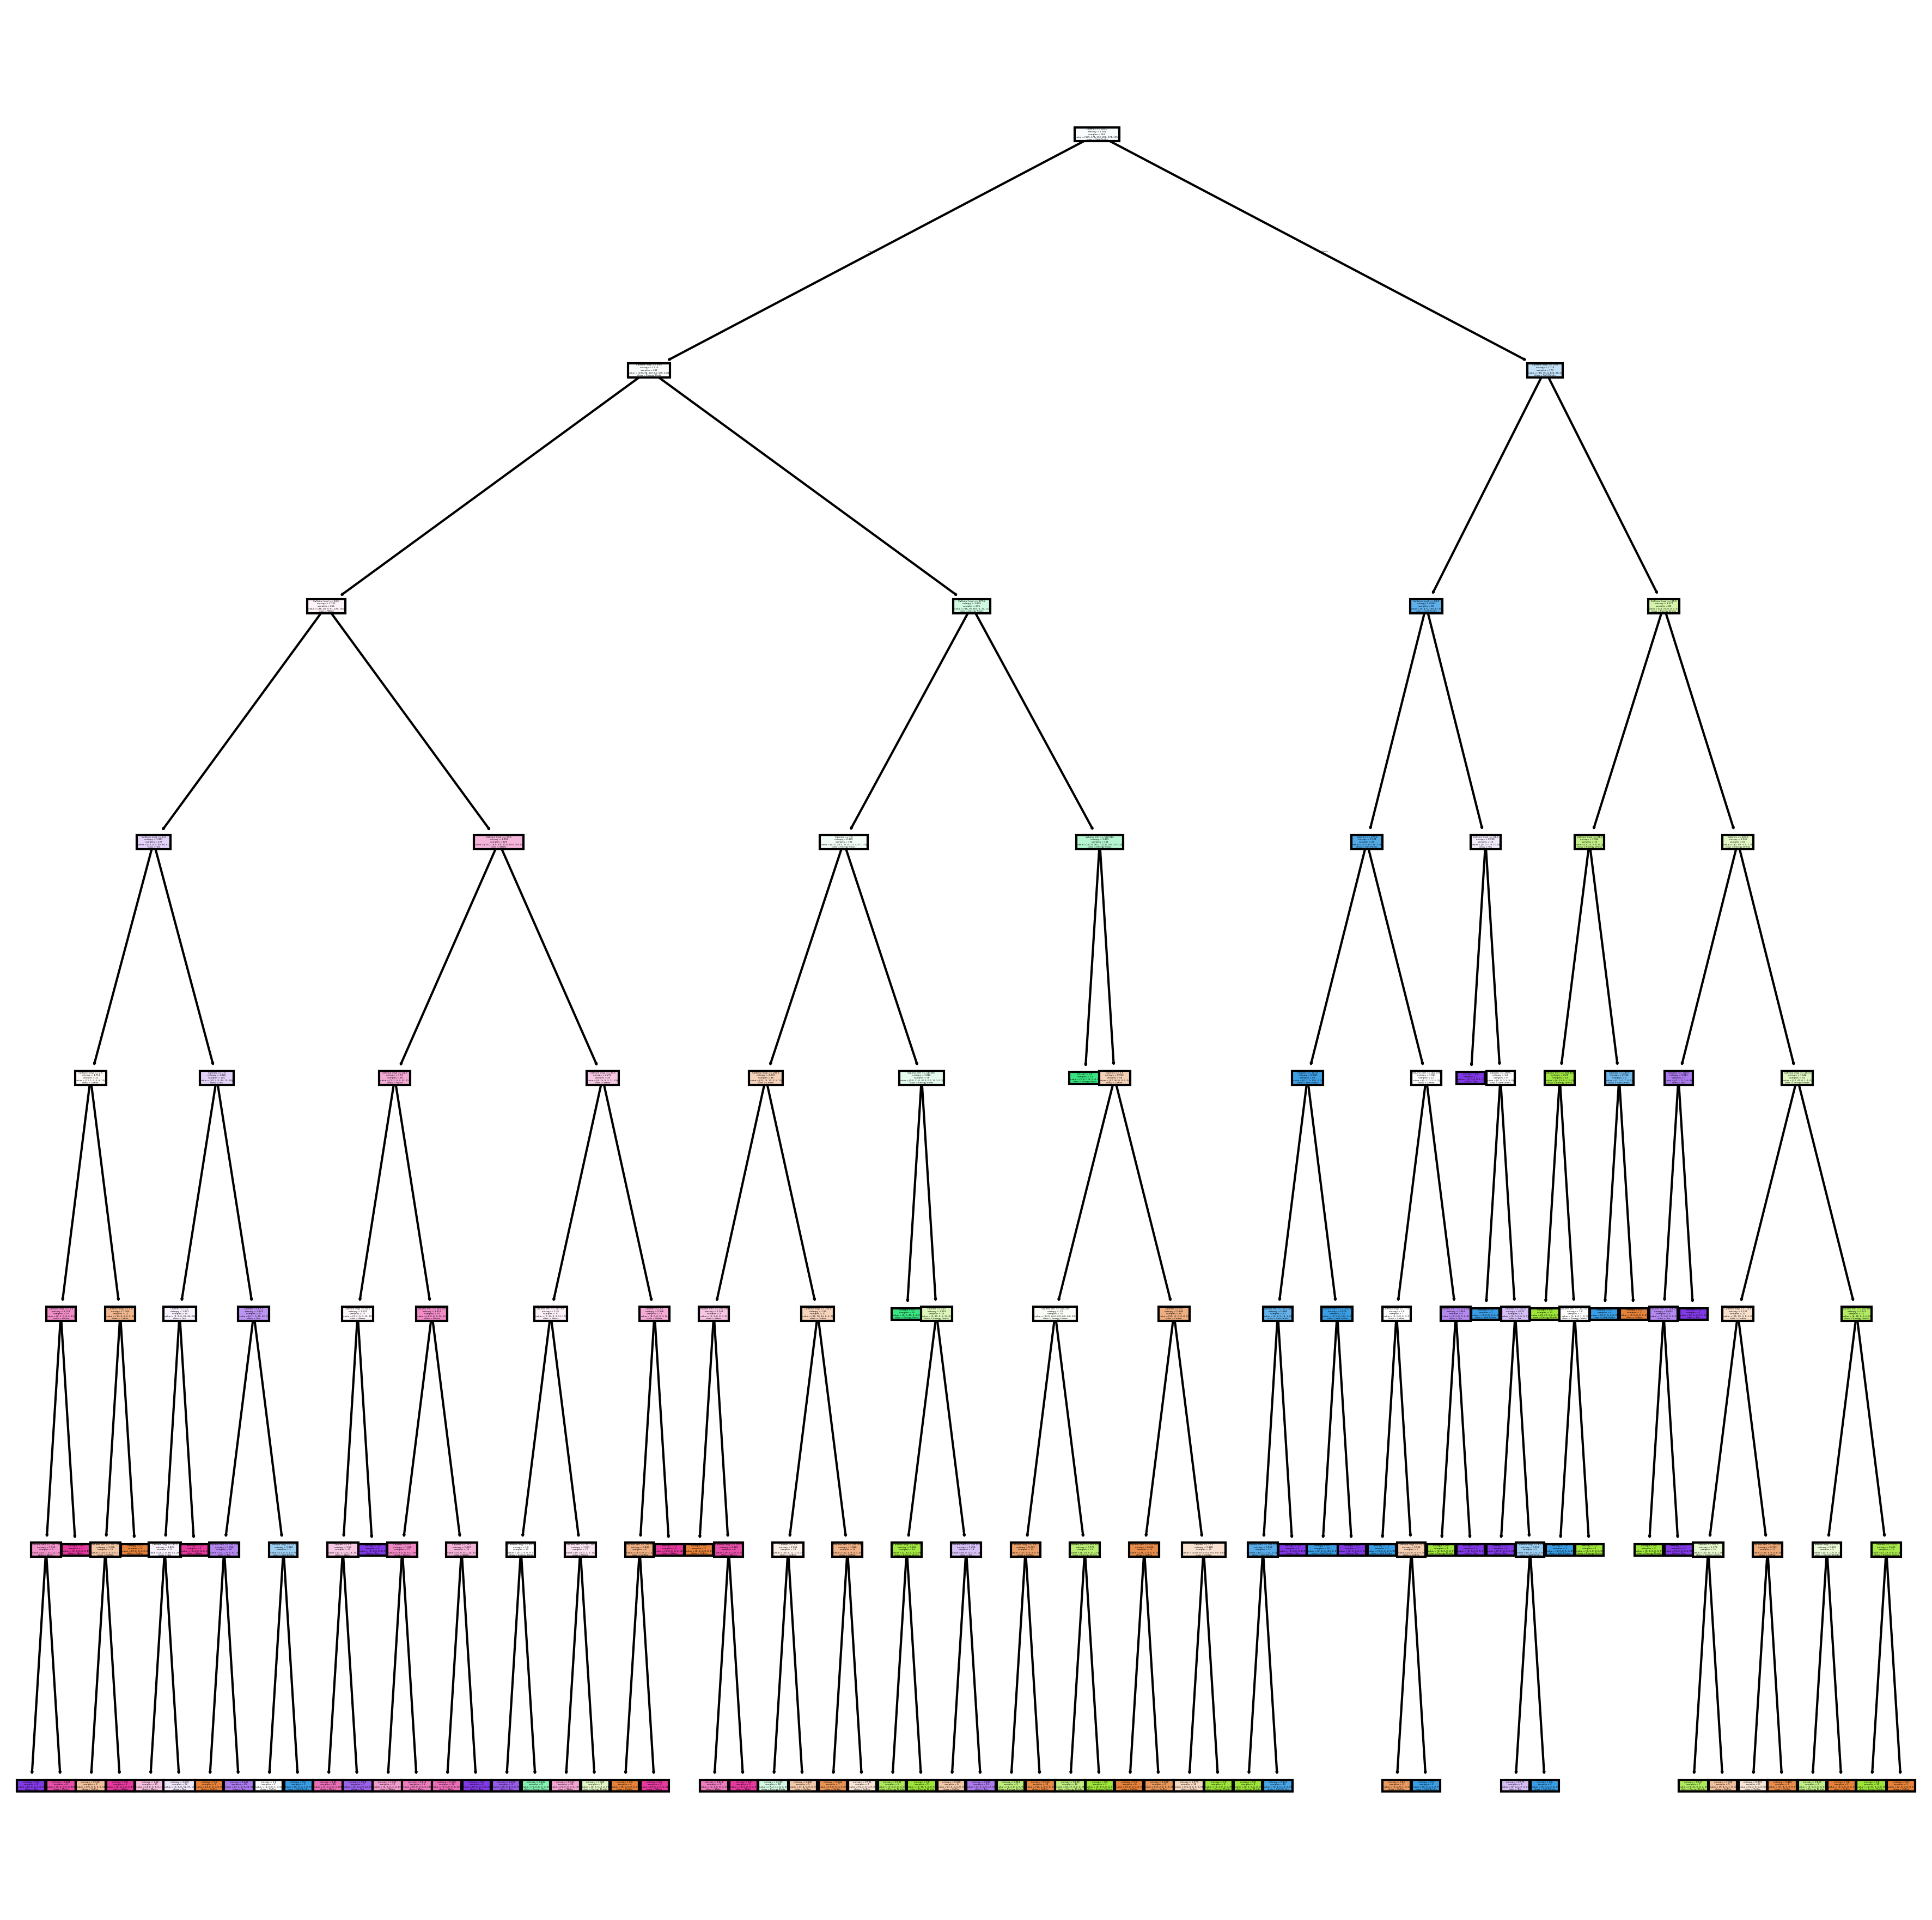

In [63]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (15,15), dpi=300)

tree.plot_tree(rf.estimators_[0],
               feature_names = label_names,
               class_names=class_names,
               filled = True)

fig.savefig('imagename.png')

In [64]:
y_predito_random_forest = rf.predict(x_test)

In [65]:
print(accuracy_score(y_test, y_predito_random_forest)) #relatório de validação das métrica de desempenho.

0.7049180327868853


In [66]:
print(rf.score(x_train, y_train))
#Mede:
##Performance do modelo
##Em dados reais
##Sem oversampling
##Serve para verificar generalização no treino original
#Ou seja:"Como o modelo treinado com SMOTE se comporta quando volto para dados reais?”


print(rf.score(x_test, y_test))
#Mede:
##Performance real do modelo
##Em dados nunca vistos
##Sem dados sintéticos
###Esse é o score mais importante


print(rf.score(x_train_os, y_train_os))
#Você estaria medindo:
##Performance em dados sintéticos
##Criados a partir do próprio treino
##Altíssimo risco de overfitting
##Métrica inflada e pouco útil
##Na prática:Esse score não representa o mundo real.
#### Por isso, não é uma boa métrica de validação.

0.8545081967213115
0.7049180327868853
0.9047619047619048


Conclusão: O SMOTE não altera o conjunto de treino original, mas cria um novo conjunto balanceado com mais amostras das classes minoritárias. Com isso, o modelo é treinado em dados mais informativos, aprendendo melhor os padrões das classes raras, o que melhora sua performance quando avaliado em dados reais, sem modificar o formato nem o tamanho do conjunto original de treino.